In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.visualization import ZScaleInterval
from astropy.modeling import models, fitting

from scipy.ndimage import gaussian_filter
from skimage.transform import probabilistic_hough_line
from skimage.feature import canny
from skimage.draw import disk

import os

(3010, 3010)


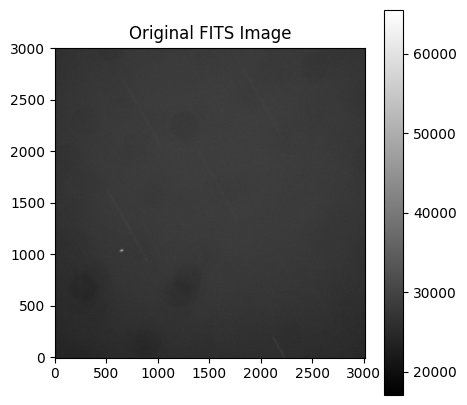

In [2]:
fits_path = r"C:\Users\astro\Downloads\28059\28059_00035.fits"

with fits.open(fits_path) as hdul:
    image = hdul[0].data.astype(float)
    header = hdul[0].header

print(image.shape)

plt.figure(figsize=(5, 5))
plt.imshow(image, cmap='gray', origin='lower')
plt.title("Original FITS Image")
plt.colorbar()
plt.show()

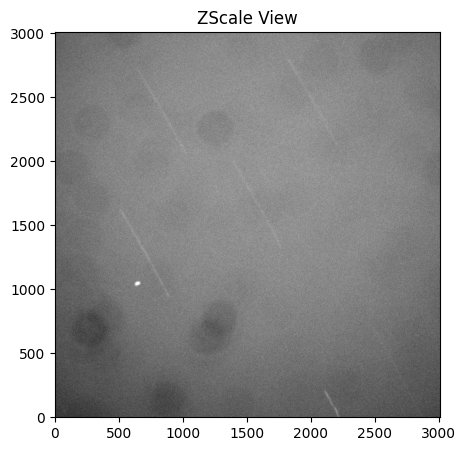

In [3]:
zscale = ZScaleInterval()
vmin, vmax = zscale.get_limits(image)

plt.figure(figsize=(5, 5))
plt.imshow(image, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
plt.title("ZScale View")
plt.show()

In [5]:
sat_x = 645
sat_y = 1044
sat_radius = 15

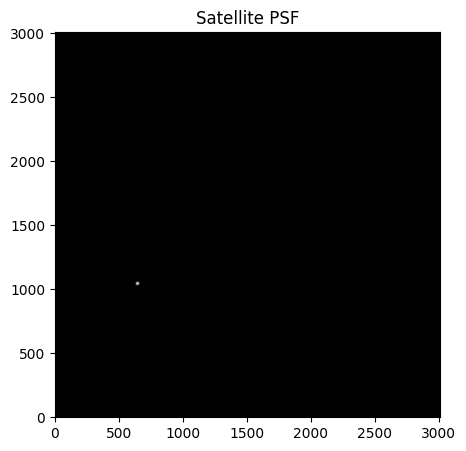

In [6]:
satellite_only = np.zeros_like(image)

yy, xx = np.indices(image.shape)

sat_mask = (xx - sat_x)**2 + (yy - sat_y)**2 <= sat_radius**2

satellite_only[sat_mask] = image[sat_mask]

plt.figure(figsize=(5, 5))
plt.imshow(satellite_only, cmap='gray', origin='lower')
plt.title("Satellite PSF")
plt.show()

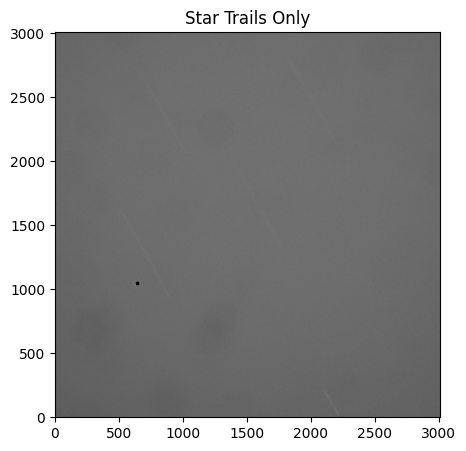

In [7]:
stars_only = image.copy()
stars_only[sat_mask] = 0

plt.figure(figsize=(5, 5))
plt.imshow(stars_only, cmap='gray', origin='lower')
plt.title("Star Trails Only")
plt.show()

In [18]:

from scipy.ndimage import gaussian_filter

# remove vertical striping
col_bg = gaussian_filter(np.median(stars_only, axis=0), sigma=20)
stars_clean = stars_only - col_bg[np.newaxis, :]

smooth = gaussian_filter(stars_clean, sigma=1.5)

threshold = np.mean(smooth) + 2.5*np.std(smooth)

binary = smooth > threshold


lines = probabilistic_hough_line(
    binary,
    threshold=5,
    line_length=300,
    line_gap=5
)
print(f"Detected {len(lines)} trails")

Detected 0 trails


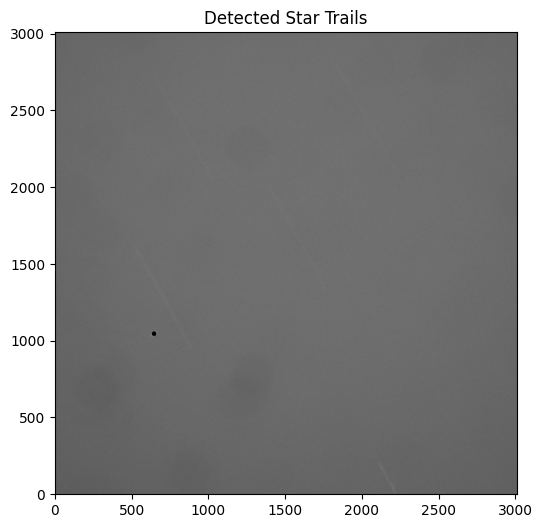

In [17]:
plt.figure(figsize=(6, 6))
plt.imshow(stars_only, cmap='gray', origin='lower')

for line in lines:
    p0, p1 = line
    plt.plot((p0[0], p1[0]), (p0[1], p1[1]), 'r')

plt.title("Detected Star Trails")
plt.show()

In [116]:
psf_fwhm = 10
sigma_psf = psf_fwhm / 2.355

def add_gaussian_psf(frame, xc, yc, flux, sigma):
    yy, xx = np.indices(frame.shape)

    psf = flux * np.exp(
        -((xx - xc)**2 + (yy - yc)**2) / (2 * sigma**2)
    )

    frame += psf

In [117]:
synthetic_frames = []

for idx, line in enumerate(lines):

    p0, p1 = line

    x0, y0 = p0
    x1, y1 = p1

    dx = x1 - x0
    dy = y1 - y0

    trail_length = np.sqrt(dx**2 + dy**2)

    n_segments = max(1, int(np.ceil(trail_length / psf_fwhm)))

    ux = dx / trail_length
    uy = dy / trail_length

    print(f"Trail {idx}: {n_segments} segments")

    for k in range(n_segments):

        frame = satellite_only.copy()

        xc = x0 + (k + 0.5) * trail_length / n_segments * ux
        yc = y0 + (k + 0.5) * trail_length / n_segments * uy

        flux = np.sum(
            stars_only[
                max(0, int(yc)-2):int(yc)+3,
                max(0, int(xc)-2):int(xc)+3
            ]
        )

        if flux <= 0:
            flux = 100

        add_gaussian_psf(frame, xc, yc, flux, sigma_psf)

        synthetic_frames.append(frame)

Trail 0: 93 segments
Trail 1: 93 segments
Trail 2: 93 segments
Trail 3: 93 segments


In [118]:
print(f"Generated {len(synthetic_frames)} synthetic frames")

Generated 372 synthetic frames


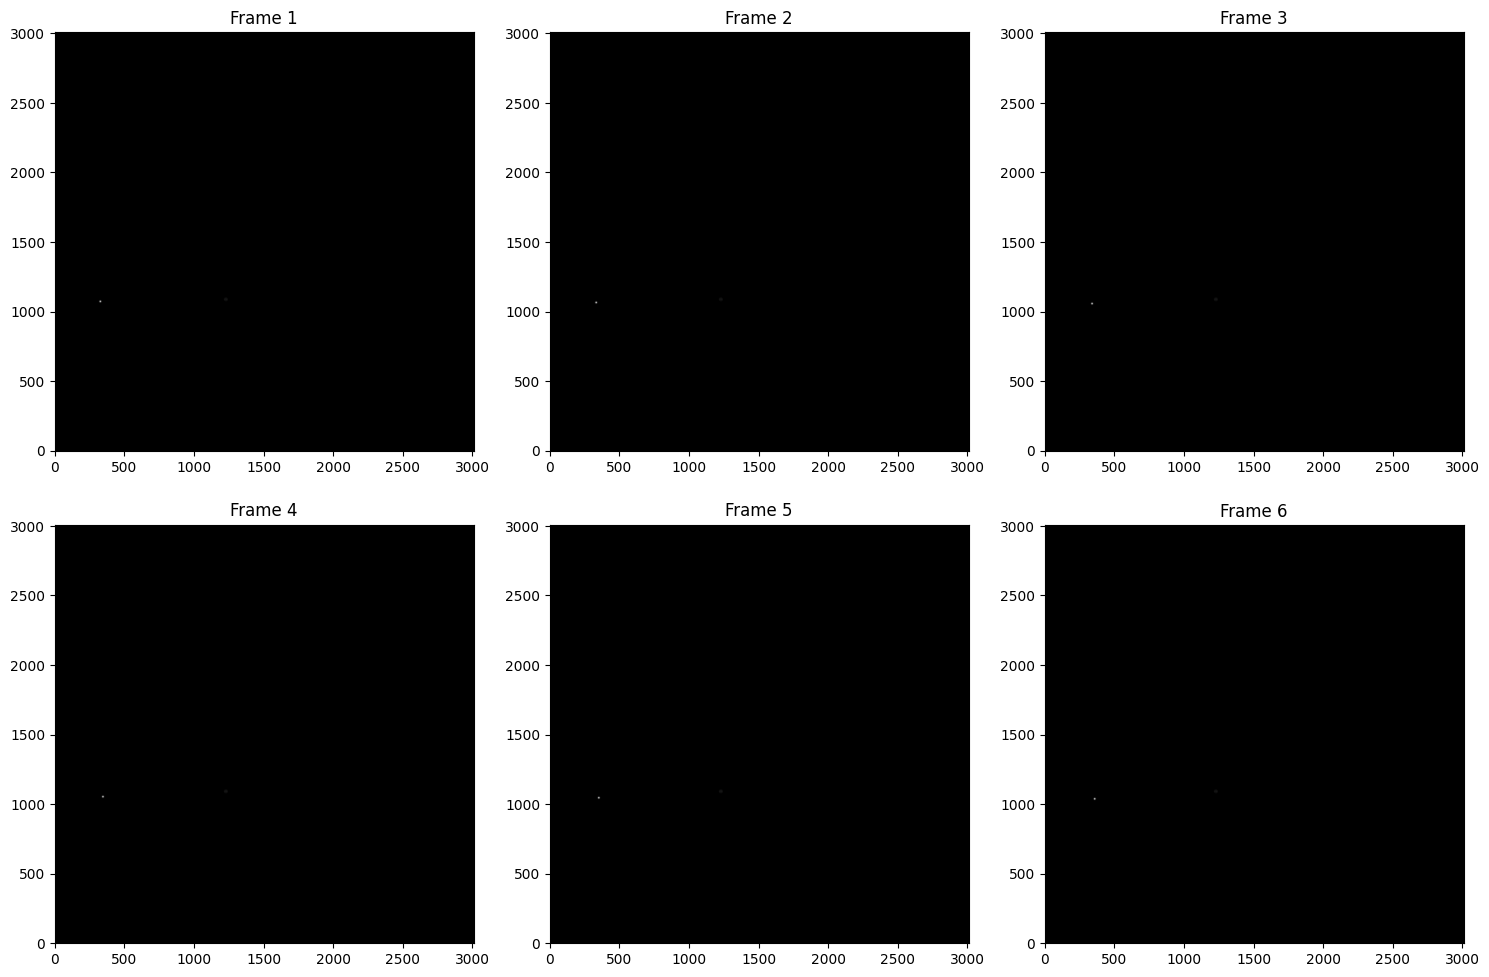

In [119]:
n_show = min(6, len(synthetic_frames))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, ax in enumerate(axes.flat[:n_show]):
    ax.imshow(synthetic_frames[i], cmap='gray', origin='lower')
    ax.set_title(f"Frame {i+1}")

plt.tight_layout()
plt.show()

In [120]:
output_dir = r"C:\Users\astro\Desktop\synthetic frames"
os.makedirs(output_dir, exist_ok=True)

for i, frame in enumerate(synthetic_frames):
    outname = os.path.join(output_dir, f"frame_{i:03d}.fits")
    fits.writeto(outname, frame, header, overwrite=True)

print("All frames saved.")

All frames saved.
